In [3]:
# --- Основни пакети за работа со податоци ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# --- Статистика и аномалии ---
from scipy import stats
from scipy.stats import boxcox
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Временски серии ---
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

# --- Предобработка и скалирање ---
from sklearn.preprocessing import StandardScaler
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# --- PCA / димензионална редукција ---
from sklearn.decomposition import PCA

# --- Машинско учење и модели ---
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Neural networks / Deep learning ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, GRU

# --- Clustering / Time Series Clustering ---
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import cdist_dtw
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import SpectralClustering
from scipy.fft import fft

c:\Users\linap\AppData\Local\Programs\Python\Python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Overview

In [1]:
from ucimlrepo import fetch_ucirepo 
  
air_quality = fetch_ucirepo(id=360) 
  
X = air_quality.data.features 
y = air_quality.data.targets 
  
print(air_quality.metadata) 
print(air_quality.variables) 


{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [4]:
df = pd.concat([X, y], axis=1)

print(type(df)) 

<class 'pandas.core.frame.DataFrame'>


In [ ]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [43]:
df.shape

(9357, 15)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [45]:
print(df.dtypes)

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object


### Data Preprocessing

##### Needed transformation

In [5]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

In [6]:
df

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406


##### Missing values

In [48]:
missing_per_colum = df.isna().sum()
print(missing_per_colum)

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


Although the dataset does not contain standard null values, according to its description, missing measurements are represented by the value -200 or -200.0.

In [7]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].replace([-200, -200.0], np.nan)
df[numeric_cols] = df[numeric_cols].astype(float)


In [27]:
missing_per_column = df.isna().sum()
print(missing_per_column)

CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [28]:
total_missing = df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

Total missing values: 16701


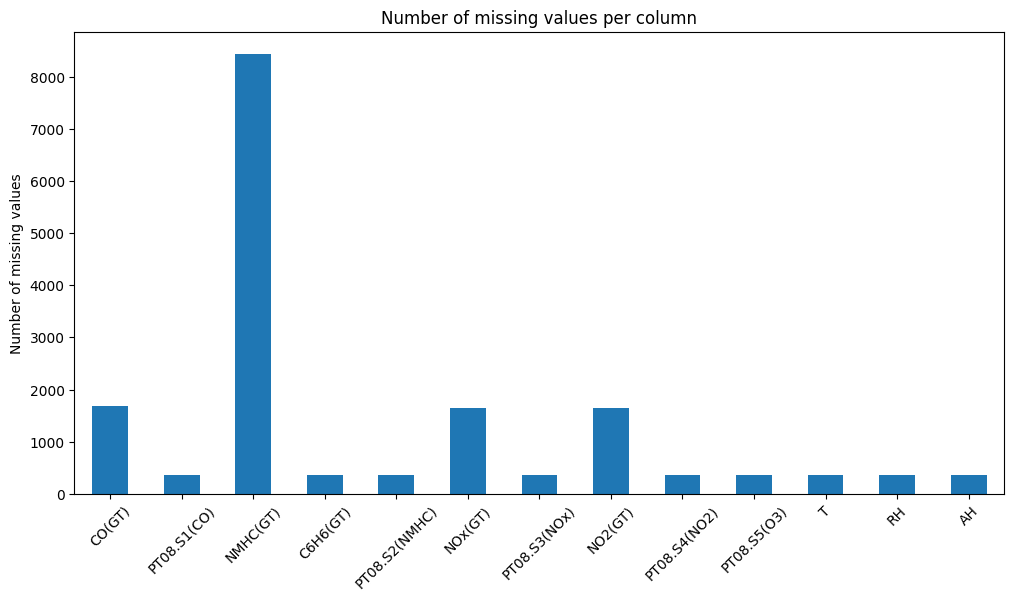

In [52]:
missing_per_column = df.isna().sum()
plt.figure(figsize=(12, 6))
missing_per_column.plot(kind='bar')
plt.title("Number of missing values per column")
plt.ylabel("Number of missing values")
plt.xticks(rotation=45)
plt.show()

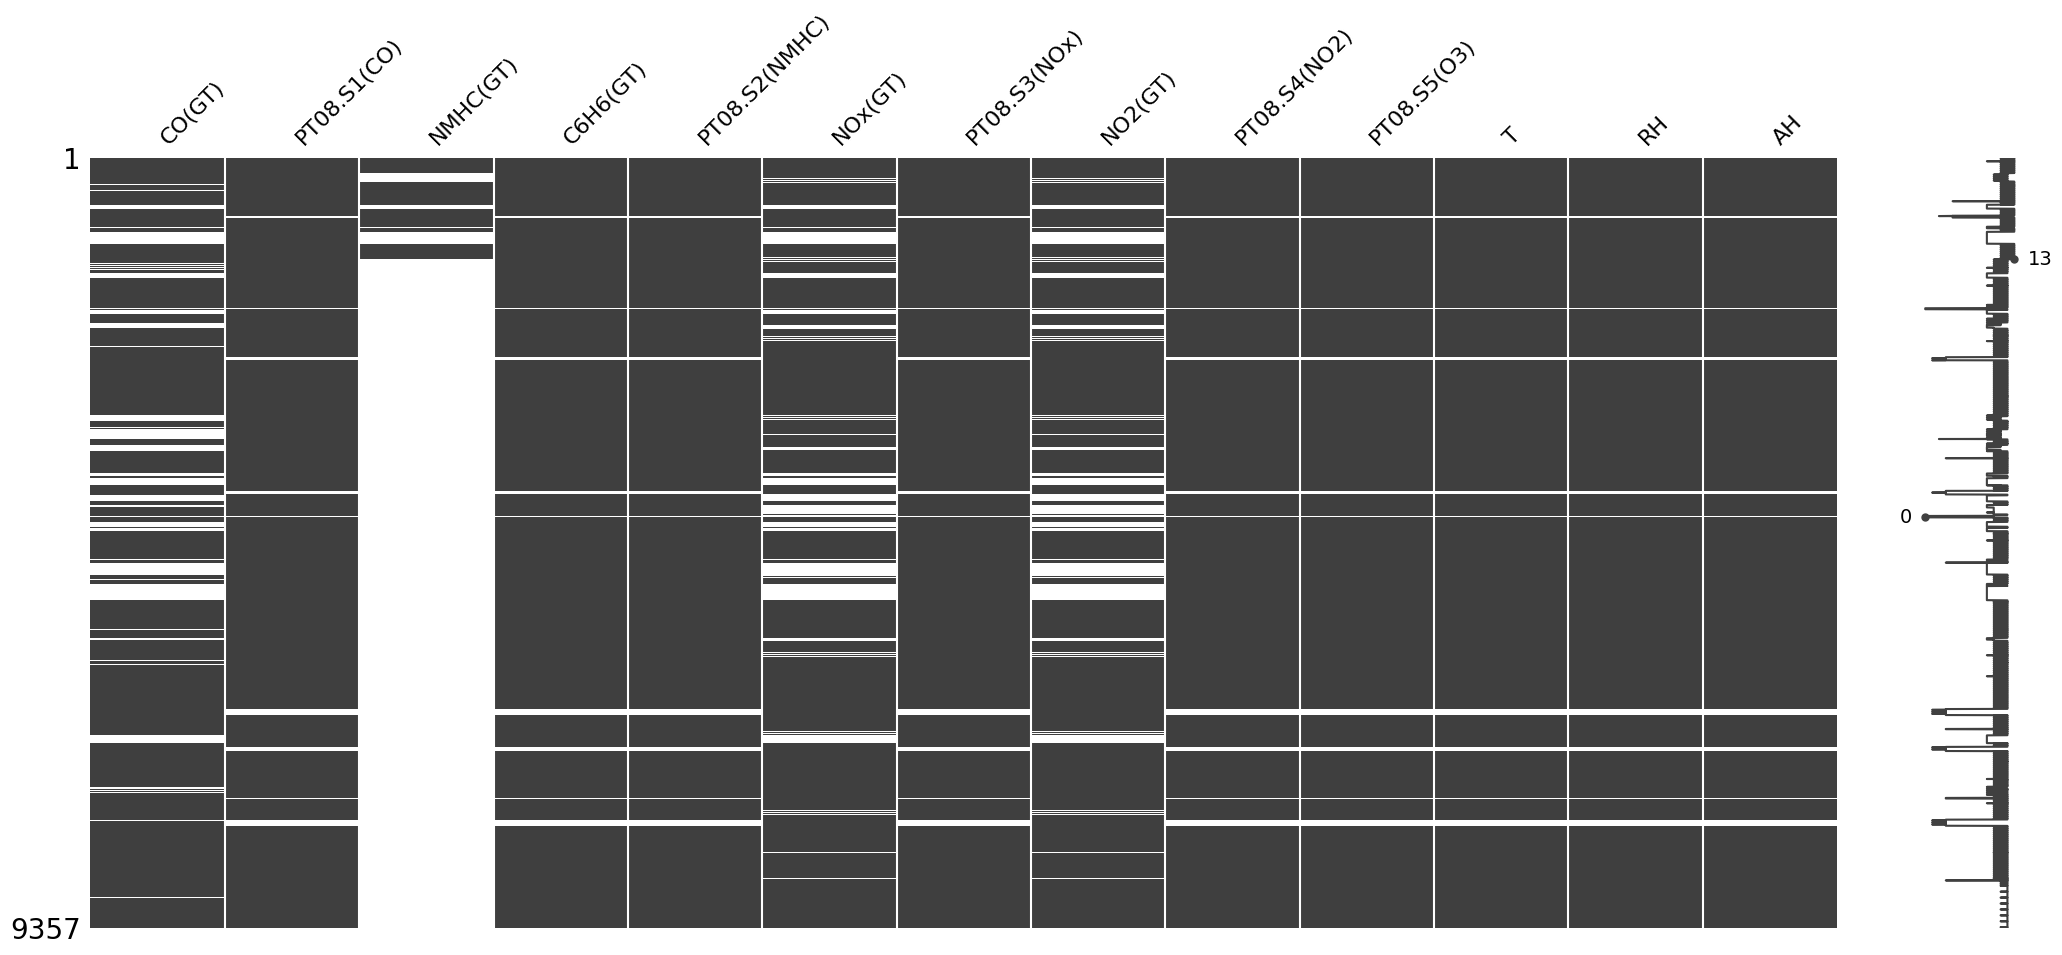

In [54]:
msno.matrix(df)
plt.show()

In [8]:
threshold = 0.8
cols_to_drop = df.columns[(df.isna().sum() / len(df)) > threshold]
df.drop(columns=cols_to_drop, inplace=True)
print("Removed columns:", cols_to_drop.to_list())

Removed columns: ['NMHC(GT)']


In [9]:
df.interpolate(method='time', inplace=True)

In [40]:
total_missing = df.isna().sum().sum()
print(f"Total missing values: {total_missing}")

Total missing values: 0


##### Outliers

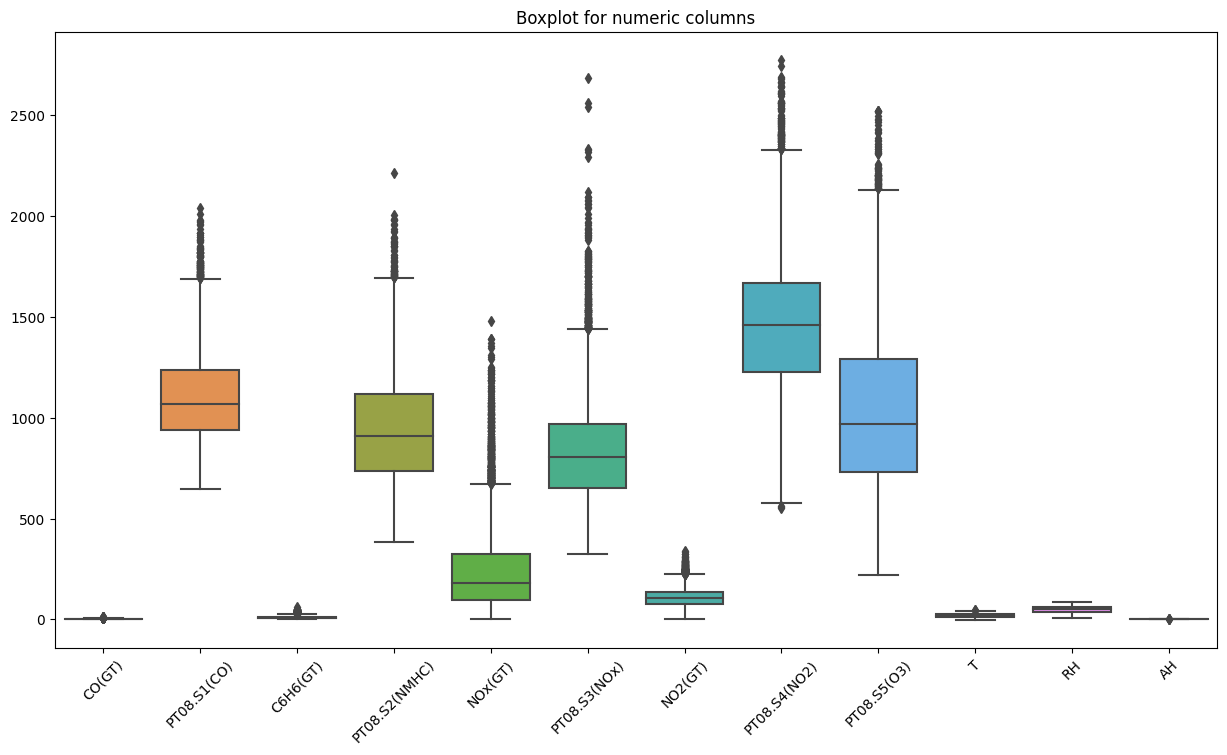

In [58]:
numeric_cols = df.select_dtypes(include=['float64']).columns

plt.figure(figsize=(15, 8))
sns.boxplot(data = df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot for numeric columns")
plt.show()

In [19]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

CO(GT): 215 outliers
PT08.S1(CO): 118 outliers
NMHC(GT): 55 outliers
C6H6(GT): 228 outliers
PT08.S2(NMHC): 65 outliers
NOx(GT): 435 outliers
PT08.S3(NOx): 241 outliers
NO2(GT): 107 outliers
PT08.S4(NO2): 97 outliers
PT08.S5(O3): 93 outliers
T: 3 outliers
RH: 0 outliers
AH: 2 outliers


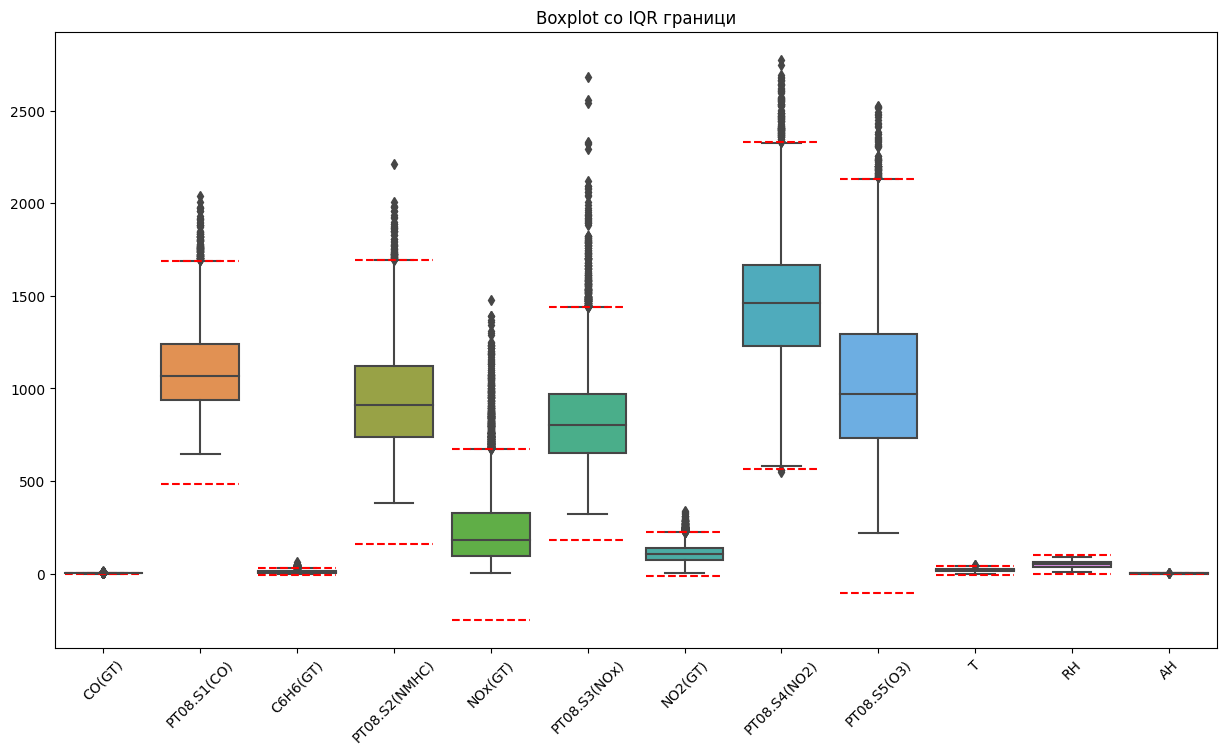

In [60]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot со IQR граници")

for i, col in enumerate(numeric_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    plt.hlines([lower, upper], i - 0.4, i + 0.4, colors='red', linestyles='dashed')
    
plt.show()

In [31]:
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers = (z_scores > 3)
print(f"Num of outliers\n: {np.sum(outliers, axis=None)}")

Num of outliers
: CO(GT)           117
PT08.S1(CO)       56
NMHC(GT)         267
C6H6(GT)         119
PT08.S2(NMHC)     37
NOx(GT)          167
PT08.S3(NOx)     111
NO2(GT)           66
PT08.S4(NO2)      43
PT08.S5(O3)       29
T                  1
RH                 0
AH                 1
dtype: int64


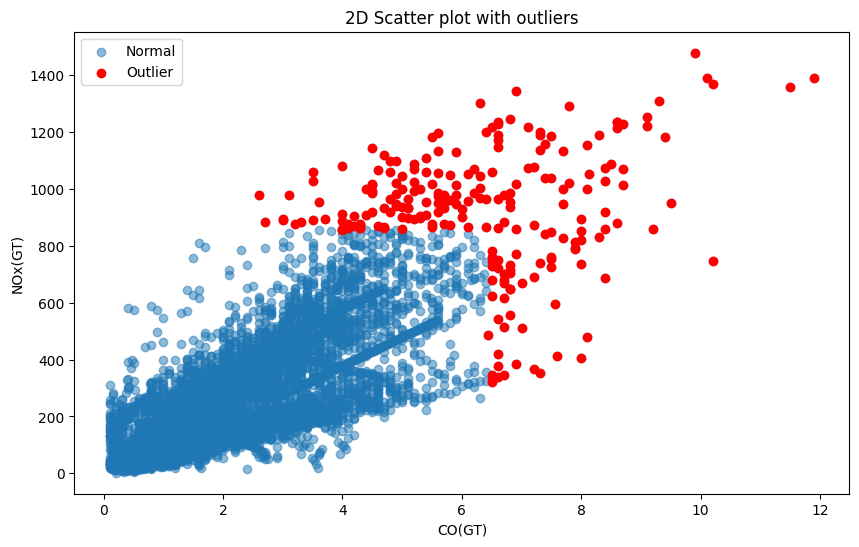

In [62]:
x_col = 'CO(GT)'
y_col = 'NOx(GT)'

z_scores = np.abs(stats.zscore(df[[x_col, y_col]].dropna()))
outliers_mask = (z_scores > 3).any(axis=1)

plt.figure(figsize=(10,6))
plt.scatter(df[x_col], df[y_col], label='Normal', alpha=0.5)
plt.scatter(df[x_col][outliers_mask], df[y_col][outliers_mask], color='red', label='Outlier')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('2D Scatter plot with outliers')
plt.legend()
plt.show()

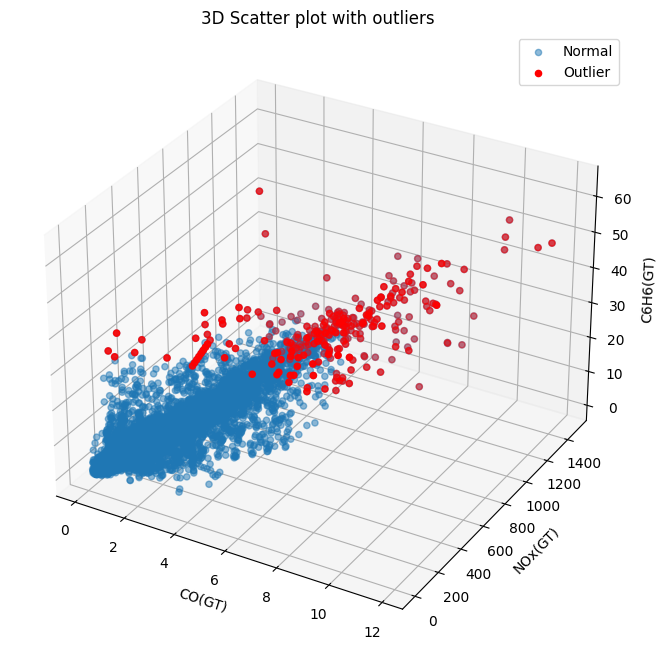

In [63]:
x_col = 'CO(GT)'
y_col = 'NOx(GT)'
z_col = 'C6H6(GT)'

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

z_scores = np.abs(stats.zscore(df[[x_col, y_col, z_col]].dropna()))
outliers_mask = (z_scores > 3).any(axis=1)

ax.scatter(df[x_col], df[y_col], df[z_col], alpha=0.5, label='Normal')
ax.scatter(df[x_col][outliers_mask], df[y_col][outliers_mask], df[z_col][outliers_mask],
           color='red', label='Outlier')

ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_zlabel(z_col)
ax.set_title('3D Scatter plot with outliers')
ax.legend()
plt.show()

In [64]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05) 
subset = df[numeric_cols].dropna()
y_pred = lof.fit_predict(subset)
subset['outlier'] = y_pred 

In [65]:
num_outliers = (subset['outlier'] == -1).sum()
print(f"Број на LOF outliers: {num_outliers}")

subset[subset['outlier']==-1].head(10)

Број на LOF outliers: 468


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,outlier
Datetime,,,,,,,,,,,,,
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,-1
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,-1
2004-03-10 23:00:00,1.2,1197.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,-1
2004-03-11 00:00:00,1.2,1185.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,-1
2004-03-11 02:00:00,0.9,1094.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,-1
2004-03-11 03:00:00,0.6,1010.0,1.7,561.0,33.0,1705.0,47.0,1235.0,501.0,10.3,60.2,0.7517,-1
2004-03-11 05:00:00,0.7,1066.0,1.1,512.0,16.0,1918.0,28.0,1182.0,422.0,11.0,56.2,0.7366,-1
2004-03-11 06:00:00,0.7,1052.0,1.6,553.0,34.0,1738.0,48.0,1221.0,472.0,10.5,58.1,0.7353,-1
2004-03-11 10:00:00,1.7,1233.0,6.3,827.0,112.0,1218.0,98.0,1446.0,860.0,10.8,58.4,0.7552,-1


##### Unique values

In [66]:
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values.")

CO(GT): 1435 unique values.
PT08.S1(CO): 1335 unique values.
C6H6(GT): 766 unique values.
PT08.S2(NMHC): 1594 unique values.
NOx(GT): 2329 unique values.
PT08.S3(NOx): 1553 unique values.
NO2(GT): 1569 unique values.
PT08.S4(NO2): 1921 unique values.
PT08.S5(O3): 2058 unique values.
T: 797 unique values.
RH: 1092 unique values.
AH: 7043 unique values.


In [67]:
for col in df.columns:
    num_unique = df[col].nunique()
    total = len(df[col])
    percent_unique = (num_unique / total) * 100
    print(f"{col}: {percent_unique:.2f}% unique values")

CO(GT): 15.34% unique values
PT08.S1(CO): 14.27% unique values
C6H6(GT): 8.19% unique values
PT08.S2(NMHC): 17.04% unique values
NOx(GT): 24.89% unique values
PT08.S3(NOx): 16.60% unique values
NO2(GT): 16.77% unique values
PT08.S4(NO2): 20.53% unique values
PT08.S5(O3): 21.99% unique values
T: 8.52% unique values
RH: 11.67% unique values
AH: 75.27% unique values


##### Duplicate values (rows)

In [68]:
df.tail()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2005-04-04 10:00:00,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
2005-04-04 13:00:00,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139
2005-04-04 14:00:00,2.2,1071.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028


In [69]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicates: {num_duplicates}")

Number of duplicates: 0


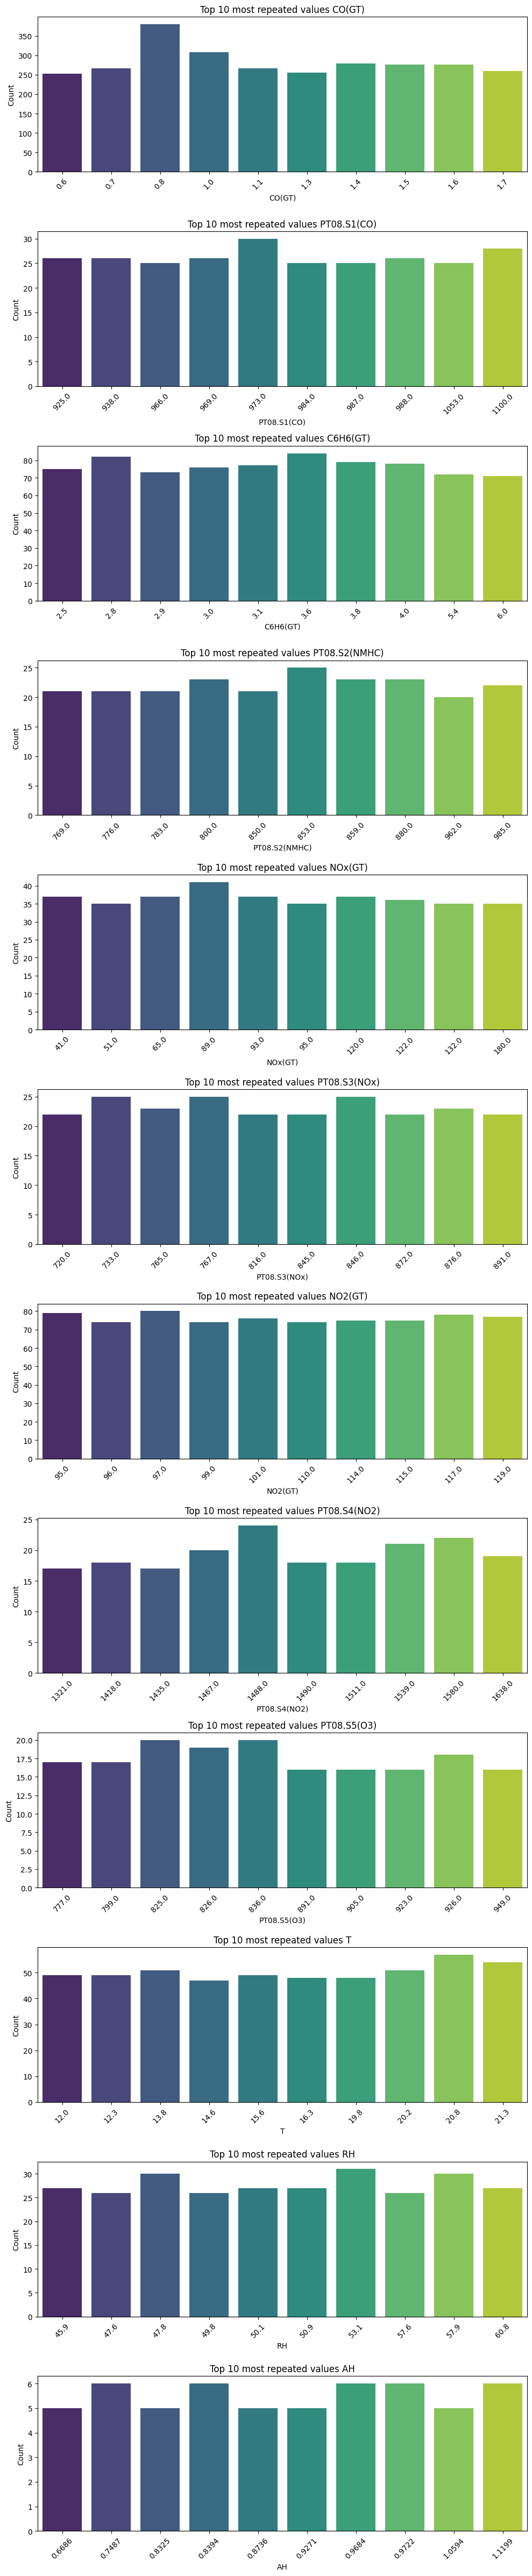

In [70]:
plt.figure(figsize=(10, len(numeric_cols)*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    
    top_vals = df[col].value_counts().head(10)
    top_df = top_vals.reset_index()
    top_df.columns = [col, "count"]
    
    sns.barplot(
        data=top_df,
        x=col,
        y="count",
        hue=col,      
        palette="viridis",
        dodge=False
    )
    
    plt.title(f"Top 10 most repeated values {col}")
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend().remove()

plt.tight_layout()
plt.show()


### Data Visualization / EDA

##### Time Series Analysis

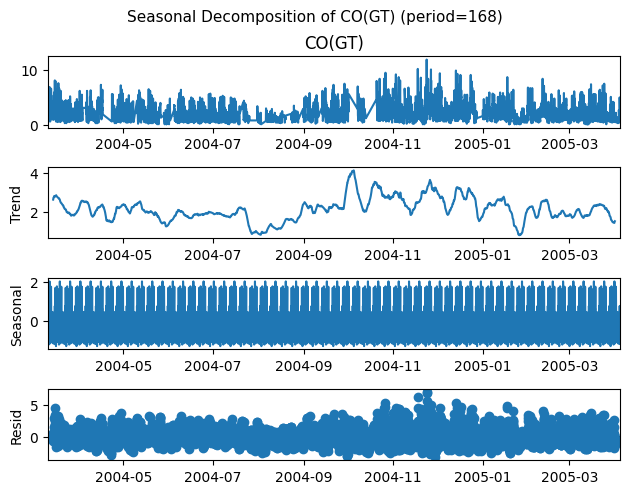

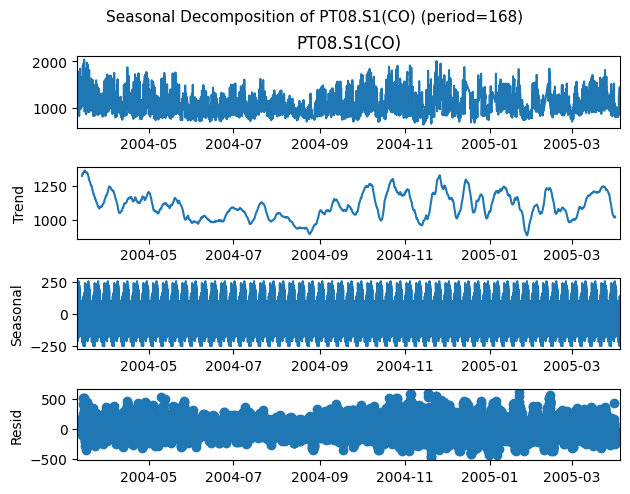

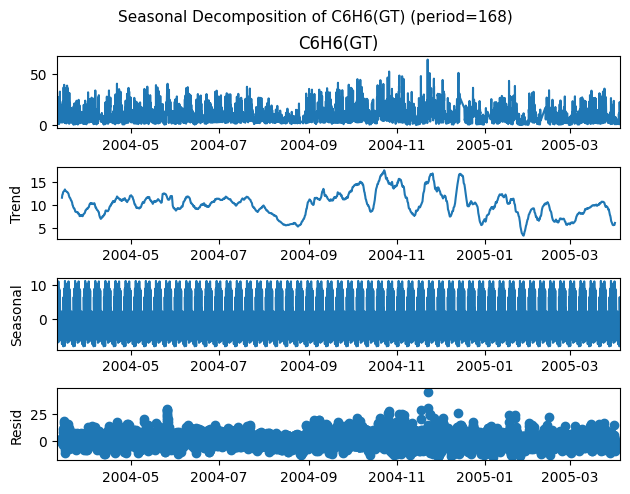

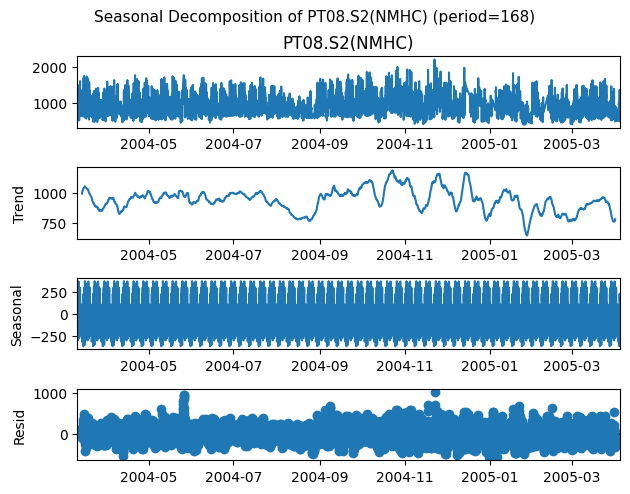

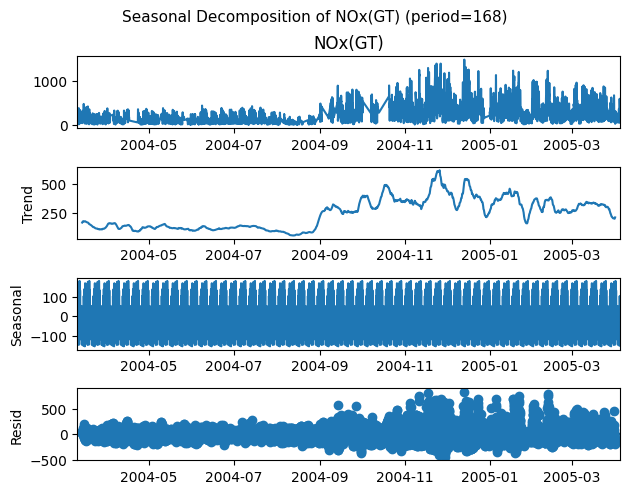

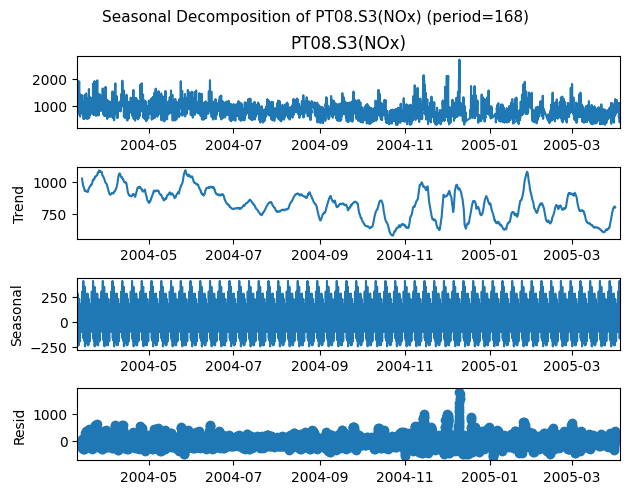

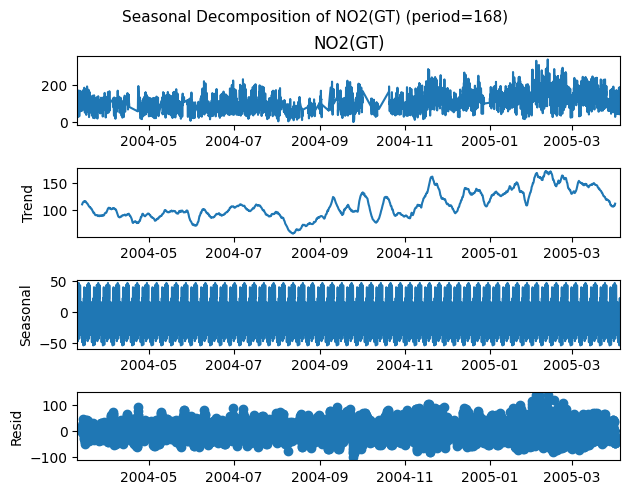

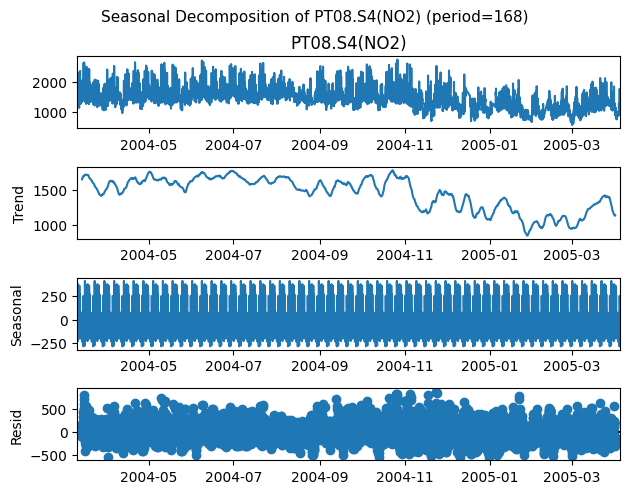

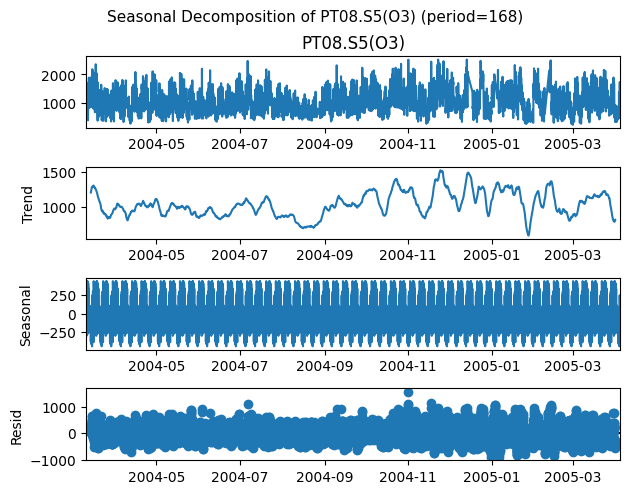

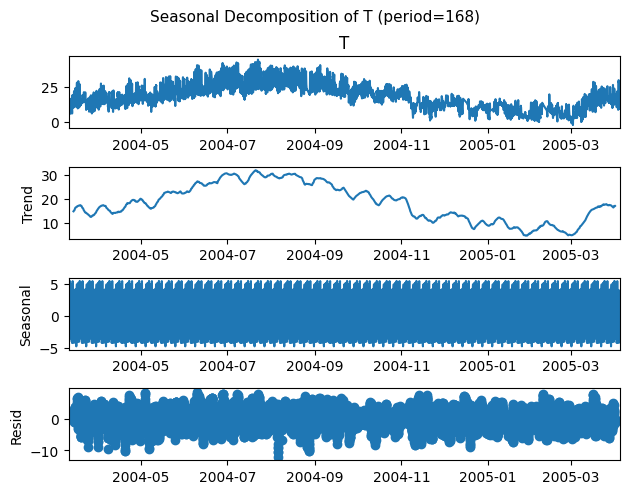

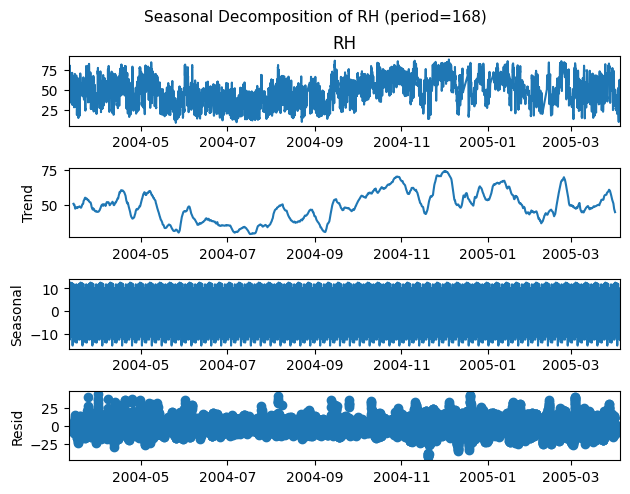

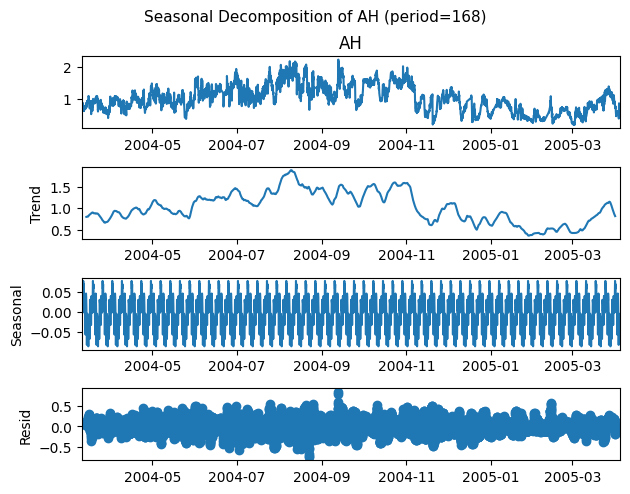

In [38]:
period = 168

for col in df.columns:
    ts = df[col]

    result = seasonal_decompose(ts, model='additive', period=period)
    result.plot()
    plt.suptitle(f"Seasonal Decomposition of {col} (period={period})", fontsize=11, y=1.02)
    plt.show()

#### Simpson's paradox

In [71]:
df_copy = df.copy()
df_copy['month'] = df_copy.index.month
df_copy['season'] = df_copy['month']%12 // 3 + 1  # 1=winter, 2=spring, 3=summer, 4=autumn/fall

In [72]:
daily_co = df_copy['CO(GT)'].resample('D').mean()

seasonal_co = df_copy.groupby(['season']).resample('D')['CO(GT)'].mean()

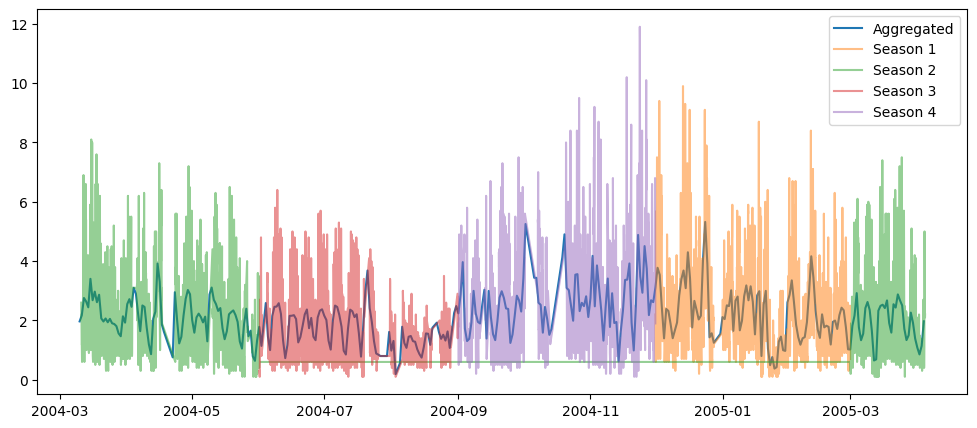

In [73]:
plt.figure(figsize=(12,5))
plt.plot(daily_co.index, daily_co.values, label='Aggregated')
for season, group in df_copy.groupby('season'):
    plt.plot(group.index, group['CO(GT)'], alpha=0.5, label=f'Season {season}')
plt.legend()
plt.show()

##### Correlation Analysis

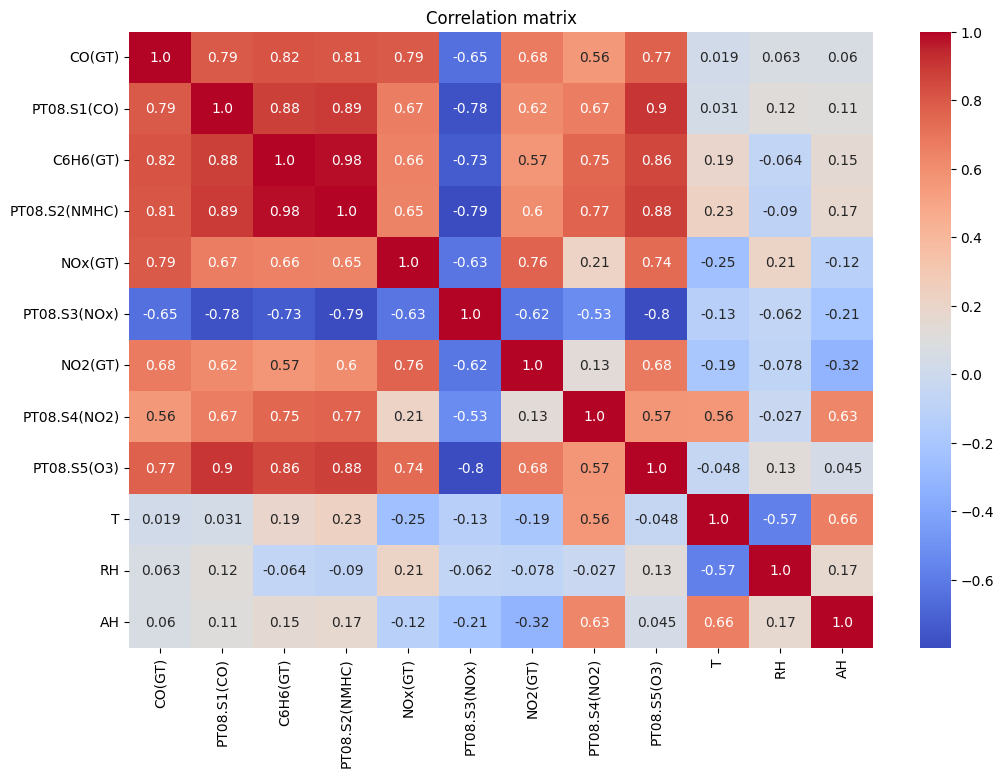

In [74]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='0.2', cmap='coolwarm', cbar=True)
plt.title("Correlation matrix")
plt.show()

In [10]:
df_model = df.copy()
cols = df.columns.to_list()

threshold = 0.8
corr_matrix = df_model[cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []
for col in upper.columns:
    correlated_cols = upper.index[upper[col] > threshold].tolist()
    to_drop.extend(correlated_cols)

to_drop = list(set(to_drop))
print("Columns to drop:", to_drop)

df_model = df_model.drop(columns=to_drop)
print("Remaining columns:", df_model.columns.to_list())

Columns to drop: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)']
Remaining columns: ['NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


##### Distribution Analysis

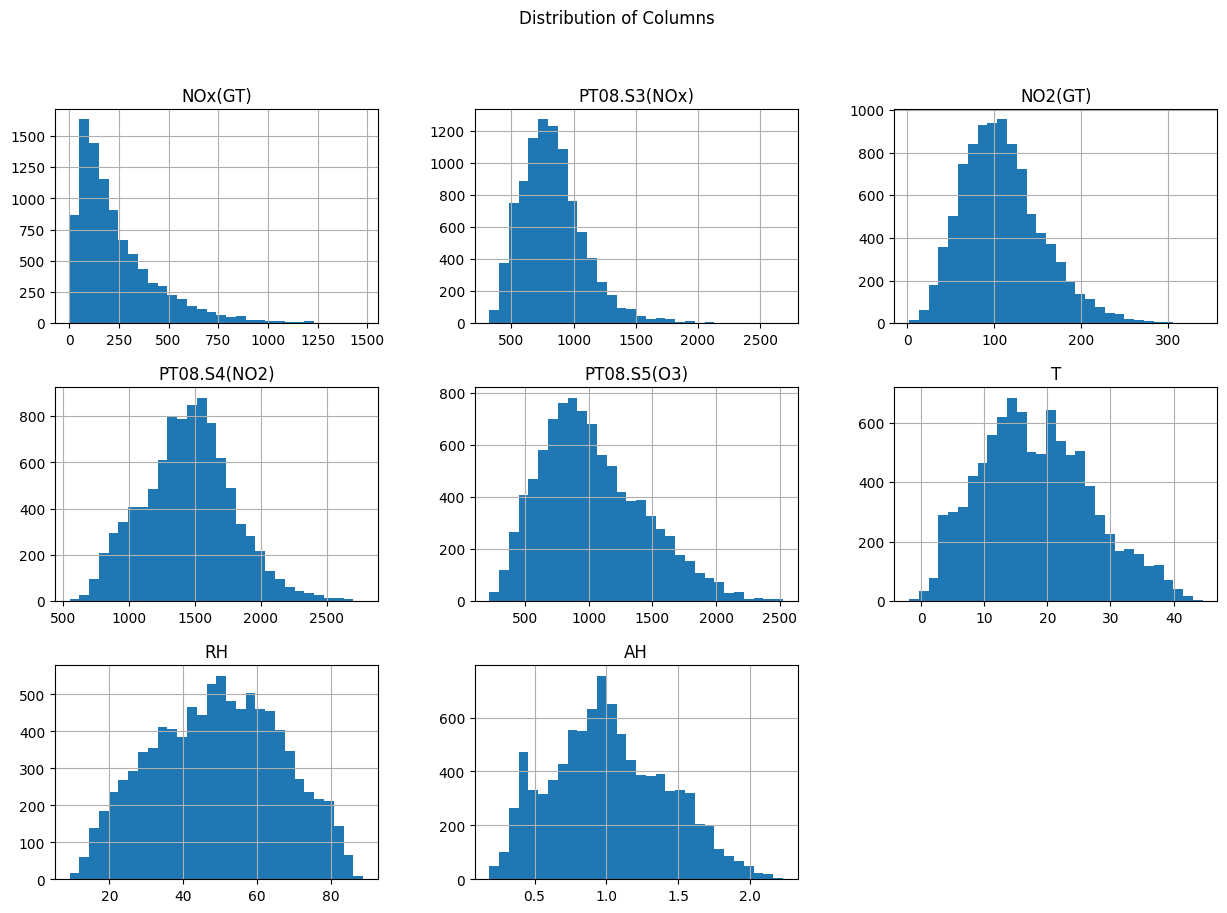

In [76]:
df_model.hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribution of Columns")
plt.show()


In [77]:
skew_values = df_model.skew()
print(skew_values)

NOx(GT)         1.697908
PT08.S3(NOx)    1.091029
NO2(GT)         0.707574
PT08.S4(NO2)    0.207815
PT08.S5(O3)     0.603006
T               0.325319
RH             -0.043924
AH              0.259390
dtype: float64


In [11]:
df_transformed = df_model.copy()

cols_to_fix = [col for col in df_model.columns if abs(df_model[col].skew()) > 1]

print("Колони за трансформација:", cols_to_fix)

for col in cols_to_fix:
    if (df_transformed[col] <= 0).any():
        df_transformed[col] = df_transformed[col] + abs(df_transformed[col].min()) + 1
    
    df_transformed[col], _ = boxcox(df_transformed[col])

print(df_transformed[cols_to_fix].skew())

Колони за трансформација: ['NOx(GT)', 'PT08.S3(NOx)']
NOx(GT)        -0.015108
PT08.S3(NOx)   -0.000152
dtype: float64


In [43]:
skew_values = df_transformed.skew()
print(skew_values)

NOx(GT)        -0.015108
PT08.S3(NOx)   -0.000152
NO2(GT)         0.707574
PT08.S4(NO2)    0.207815
PT08.S5(O3)     0.603006
T               0.325319
RH             -0.043924
AH              0.259390
dtype: float64


In [80]:
df_transformed

,NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,
2004-03-10 18:00:00,7.394882,6.264576,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,6.466335,6.349869,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,6.926623,6.326233,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,7.466412,6.291598,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,6.926623,6.370812,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,9.652166,5.716500,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,8.991981,5.810091,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,8.582201,5.808731,175.0,1241.0,1092.0,26.9,18.3,0.6406


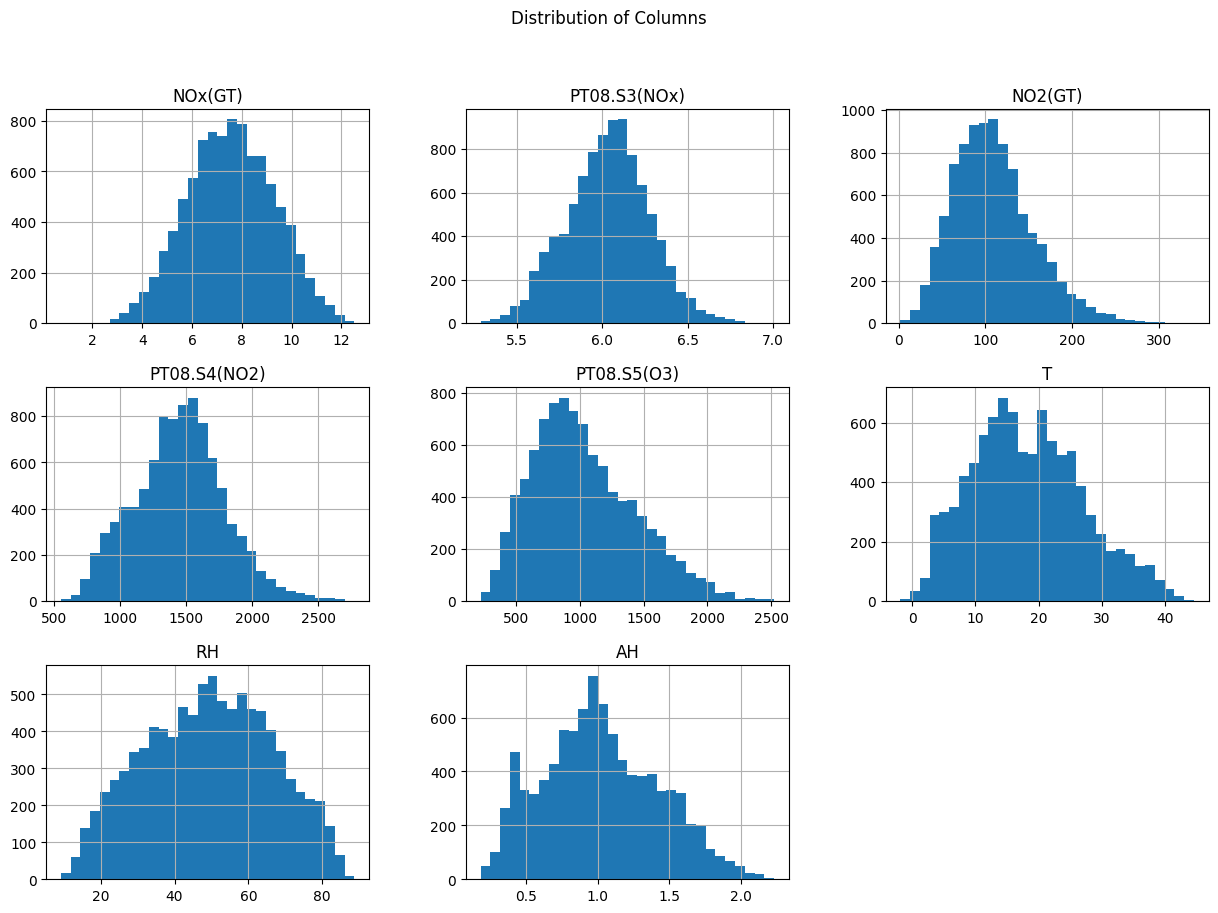

In [81]:
df_transformed.hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribution of Columns")
plt.show()

##### PCA

In [12]:
X_vif = df_transformed.copy()
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

        Feature        VIF
0       NOx(GT)  83.872801
1  PT08.S3(NOx)  74.411707
2       NO2(GT)  27.568659
3  PT08.S4(NO2)  85.182631
4   PT08.S5(O3)  39.777527
5             T  73.980501
6            RH  71.359852
7            AH  68.577657


In [13]:
cols_for_pca = [col for col in df_transformed.columns if col not in to_drop]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_transformed[cols_for_pca])

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Shape na PCA data:", X_pca.shape)
print("Variance explained:", pca.explained_variance_ratio_.cumsum())

Shape na PCA data: (9357, 5)
Variance explained: [0.4351408  0.736875   0.90137426 0.94479657 0.96853022]


In [14]:
datetimes = df_transformed.index

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=datetimes)

print(df_pca)

                          PC1       PC2       PC3       PC4       PC5
Datetime                                                             
2004-03-10 18:00:00 -0.010964 -0.409318  0.048978  1.134399  0.833332
2004-03-10 19:00:00 -1.119768 -0.473434  0.058705  1.037485  0.717972
2004-03-10 20:00:00 -0.591651 -0.755030 -0.177719  0.881355  0.955909
2004-03-10 21:00:00 -0.088301 -0.876133 -0.493947  0.832527  1.018797
2004-03-10 22:00:00 -0.649552 -0.924282 -0.467137  0.776146  1.063058
...                       ...       ...       ...       ...       ...
2005-04-04 10:00:00  2.651773 -0.496135  1.780904 -0.136524 -0.389453
2005-04-04 11:00:00  1.485162 -0.402537  2.177319 -0.546508 -0.301920
2005-04-04 12:00:00  1.070349 -0.235564  2.579728 -0.623024 -0.376675
2005-04-04 13:00:00 -0.093230 -0.443358  2.956288 -0.891453 -0.468742
2005-04-04 14:00:00  0.335619 -0.384910  3.030828 -0.849884 -0.381790

[9357 rows x 5 columns]


In [47]:
X_vif = df_pca.copy()
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

  Feature  VIF
0     PC1  1.0
1     PC2  1.0
2     PC3  1.0
3     PC4  1.0
4     PC5  1.0


In [89]:
for i, col in enumerate(df_pca.columns):
    print(f"Компонента {col}:")
    print(pca.components_[i])

Компонента PC1:
[ 0.46868976 -0.4989795   0.43139672  0.29438307  0.50243748 -0.01021222
  0.06674983  0.03976932]
Компонента PC2:
[-0.20098214 -0.08653561 -0.22210271  0.47043883  0.01020592  0.58871565
 -0.18781476  0.5472758 ]
Компонента PC3:
[ 0.02837865  0.03191148  0.28889994 -0.11401885 -0.03156     0.30159361
 -0.81846349 -0.37399947]
Компонента PC4:
[-0.43929196  0.06923521 -0.26032185  0.50929003  0.44508204 -0.26639935
 -0.08714684 -0.44544814]
Компонента PC5:
[ 0.02396241  0.64862742  0.58433379  0.42745435 -0.15503055  0.01483295
  0.1719344   0.02700292]


In [92]:
for i, col in enumerate(df_pca.columns):
    print(f"Компонента {col}:")
    for feature, weight in zip(df_transformed.columns, pca.components_[i]):
        print(f"  {feature}: {weight:.4f}")
    print()

Компонента PC1:
  NOx(GT): 0.4687
  PT08.S3(NOx): -0.4990
  NO2(GT): 0.4314
  PT08.S4(NO2): 0.2944
  PT08.S5(O3): 0.5024
  T: -0.0102
  RH: 0.0667
  AH: 0.0398

Компонента PC2:
  NOx(GT): -0.2010
  PT08.S3(NOx): -0.0865
  NO2(GT): -0.2221
  PT08.S4(NO2): 0.4704
  PT08.S5(O3): 0.0102
  T: 0.5887
  RH: -0.1878
  AH: 0.5473

Компонента PC3:
  NOx(GT): 0.0284
  PT08.S3(NOx): 0.0319
  NO2(GT): 0.2889
  PT08.S4(NO2): -0.1140
  PT08.S5(O3): -0.0316
  T: 0.3016
  RH: -0.8185
  AH: -0.3740

Компонента PC4:
  NOx(GT): -0.4393
  PT08.S3(NOx): 0.0692
  NO2(GT): -0.2603
  PT08.S4(NO2): 0.5093
  PT08.S5(O3): 0.4451
  T: -0.2664
  RH: -0.0871
  AH: -0.4454

Компонента PC5:
  NOx(GT): 0.0240
  PT08.S3(NOx): 0.6486
  NO2(GT): 0.5843
  PT08.S4(NO2): 0.4275
  PT08.S5(O3): -0.1550
  T: 0.0148
  RH: 0.1719
  AH: 0.0270



### Models/Algorithms

##### LSTM

In [15]:
n_steps = 24
feature_cols = df_pca.columns.tolist()

data = df_pca.values

X, y = [], []
for i in range(n_steps, len(data)):
    X.append(data[i-n_steps:i])
    y.append(data[i, :])        

X, y = np.array(X), np.array(y)
print("X shape:", X.shape) 
print("y shape:", y.shape) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(y.shape[1])) 
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


X shape: (9333, 24, 5)
y shape: (9333, 5)
Epoch 1/20
234/234 [==============================] - 4s 11ms/step - loss: 0.4401 - val_loss: 0.2249
Epoch 2/20
234/234 [==============================] - 2s 8ms/step - loss: 0.1557 - val_loss: 0.1722
Epoch 3/20
234/234 [==============================] - 2s 8ms/step - loss: 0.1411 - val_loss: 0.1642
Epoch 4/20
234/234 [==============================] - 2s 8ms/step - loss: 0.1333 - val_loss: 0.1658
Epoch 5/20
234/234 [==============================] - 2s 8ms/step - loss: 0.1295 - val_loss: 0.1497
Epoch 6/20
234/234 [==============================] - 2s 8ms/step - loss: 0.1273 - val_loss: 0.1510
Epoch 7/20
234/234 [==============================] - 2s 8ms/step - loss: 0.1247 - val_loss: 0.1505
Epoch 8/20
234/234 [==============================] - 2s 9ms/step - loss: 0.1223 - val_loss: 0.1562
Epoch 9/20
234/234 [==============================] - 2s 10ms/step - loss: 0.1202 - val_loss: 0.1455
Epoch 10/20
234/234 [==============================] - 2

In [16]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.1327
RMSE: 0.3643
MAE: 0.2299
R²: 0.8464


In [17]:
baseline_pred = model.predict(X_test)
baseline_mse = mean_squared_error(y_test, baseline_pred)

importances = []
for i in range(X_test.shape[2]):
    X_test_permuted = X_test.copy()
    np.random.shuffle(X_test_permuted[:, :, i])
    permuted_pred = model.predict(X_test_permuted)
    permuted_mse = mean_squared_error(y_test, permuted_pred)
    importances.append(permuted_mse - baseline_mse)

for col, imp in zip(feature_cols, importances):
    print(col, imp)

PC1 1.3995244680890284
PC2 0.33525561972254314
PC3 0.4357352917282127
PC4 0.05020682333851417
PC5 0.04945003746394064


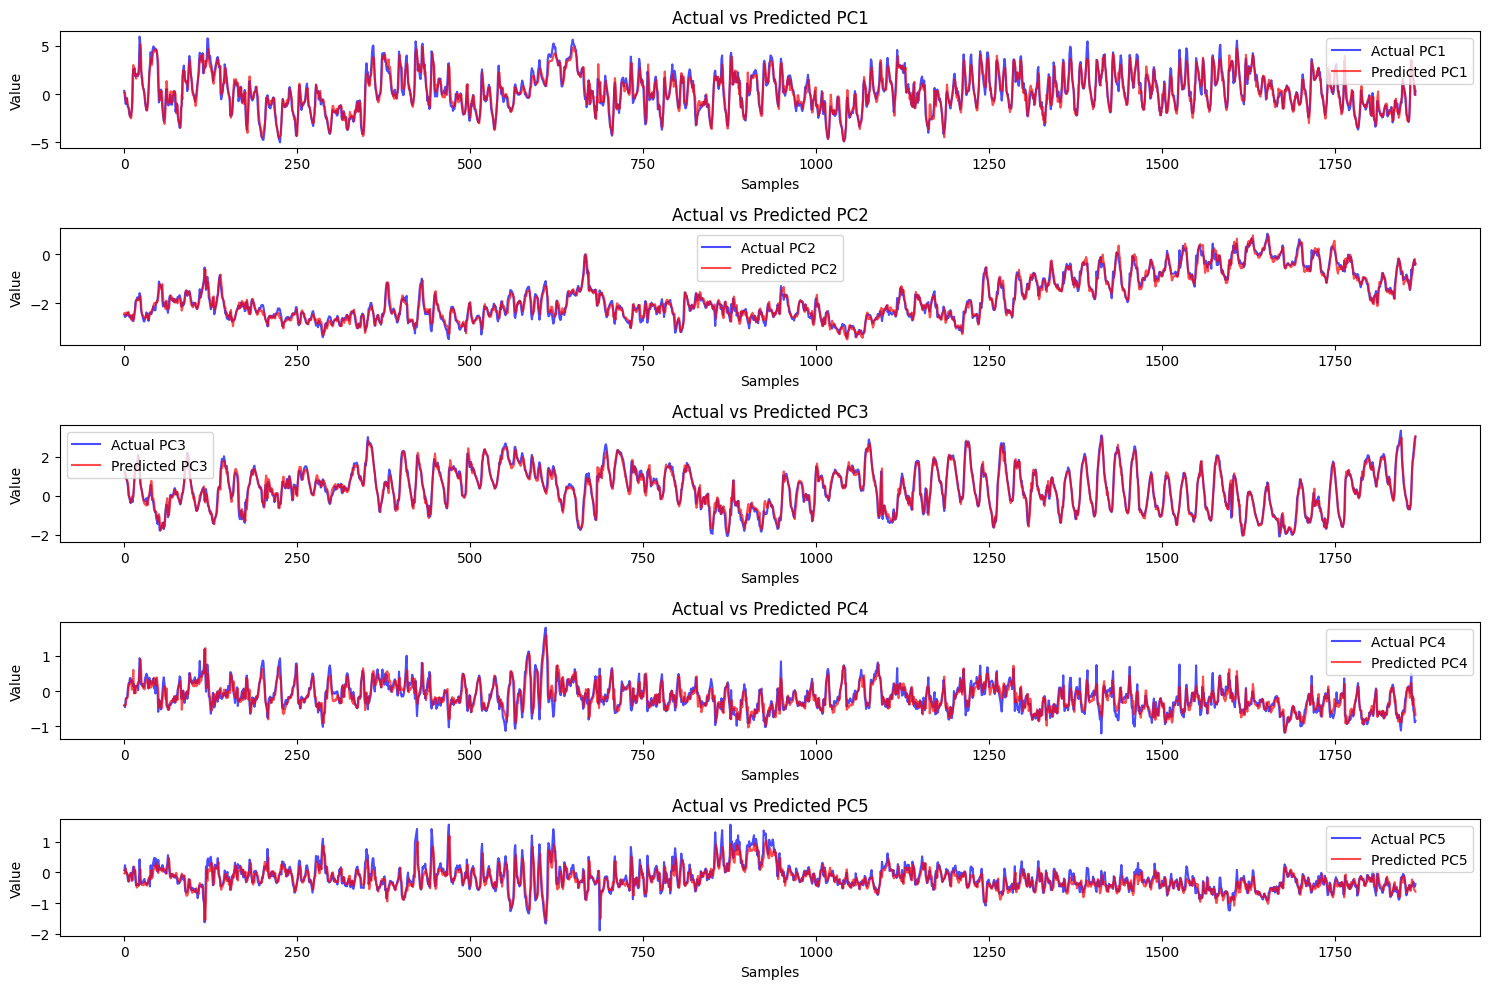

In [18]:
pcs = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
plt.figure(figsize=(15, 10))

for i, pc in enumerate(pcs):
    plt.subplot(len(pcs), 1, i+1)
    plt.plot(y_test[:, i], label=f'Actual {pc}', color='blue', alpha=0.7)
    plt.plot(y_pred[:, i], label=f'Predicted {pc}', color='red', alpha=0.7)
    plt.title(f'Actual vs Predicted {pc}')
    plt.xlabel('Samples')
    plt.ylabel('Value')
    plt.legend()

plt.tight_layout()
plt.show()

#### Bidirectional LSTM Multivariate

In [52]:
n_steps = 24
pcs = df_pca.columns.tolist()
data = df_pca.values

X, y = [], []
for i in range(n_steps, len(data)):
    X.append(data[i-n_steps:i, :]) 
    y.append(data[i, :])           

X, y = np.array(X), np.array(y)
print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = Sequential()
model.add(Bidirectional(LSTM(50, activation='tanh'), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(y_train.shape[1]))  
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

X shape: (9333, 24, 5)
y shape: (9333, 5)
Epoch 1/20
234/234 [==============================] - 10s 16ms/step - loss: 0.4085 - val_loss: 0.2888
Epoch 2/20
234/234 [==============================] - 3s 14ms/step - loss: 0.1557 - val_loss: 0.1780
Epoch 3/20
234/234 [==============================] - 3s 11ms/step - loss: 0.1297 - val_loss: 0.1571
Epoch 4/20
234/234 [==============================] - 3s 12ms/step - loss: 0.1220 - val_loss: 0.1533
Epoch 5/20
234/234 [==============================] - 3s 12ms/step - loss: 0.1175 - val_loss: 0.1562
Epoch 6/20
234/234 [==============================] - 3s 12ms/step - loss: 0.1141 - val_loss: 0.1463
Epoch 7/20
234/234 [==============================] - 3s 12ms/step - loss: 0.1115 - val_loss: 0.1485
Epoch 8/20
234/234 [==============================] - 3s 12ms/step - loss: 0.1091 - val_loss: 0.1467
Epoch 9/20
234/234 [==============================] - 3s 13ms/step - loss: 0.1069 - val_loss: 0.1436
Epoch 10/20
234/234 [===========================

In [53]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.1443
RMSE: 0.3798
MAE: 0.2413
R²: 0.8387


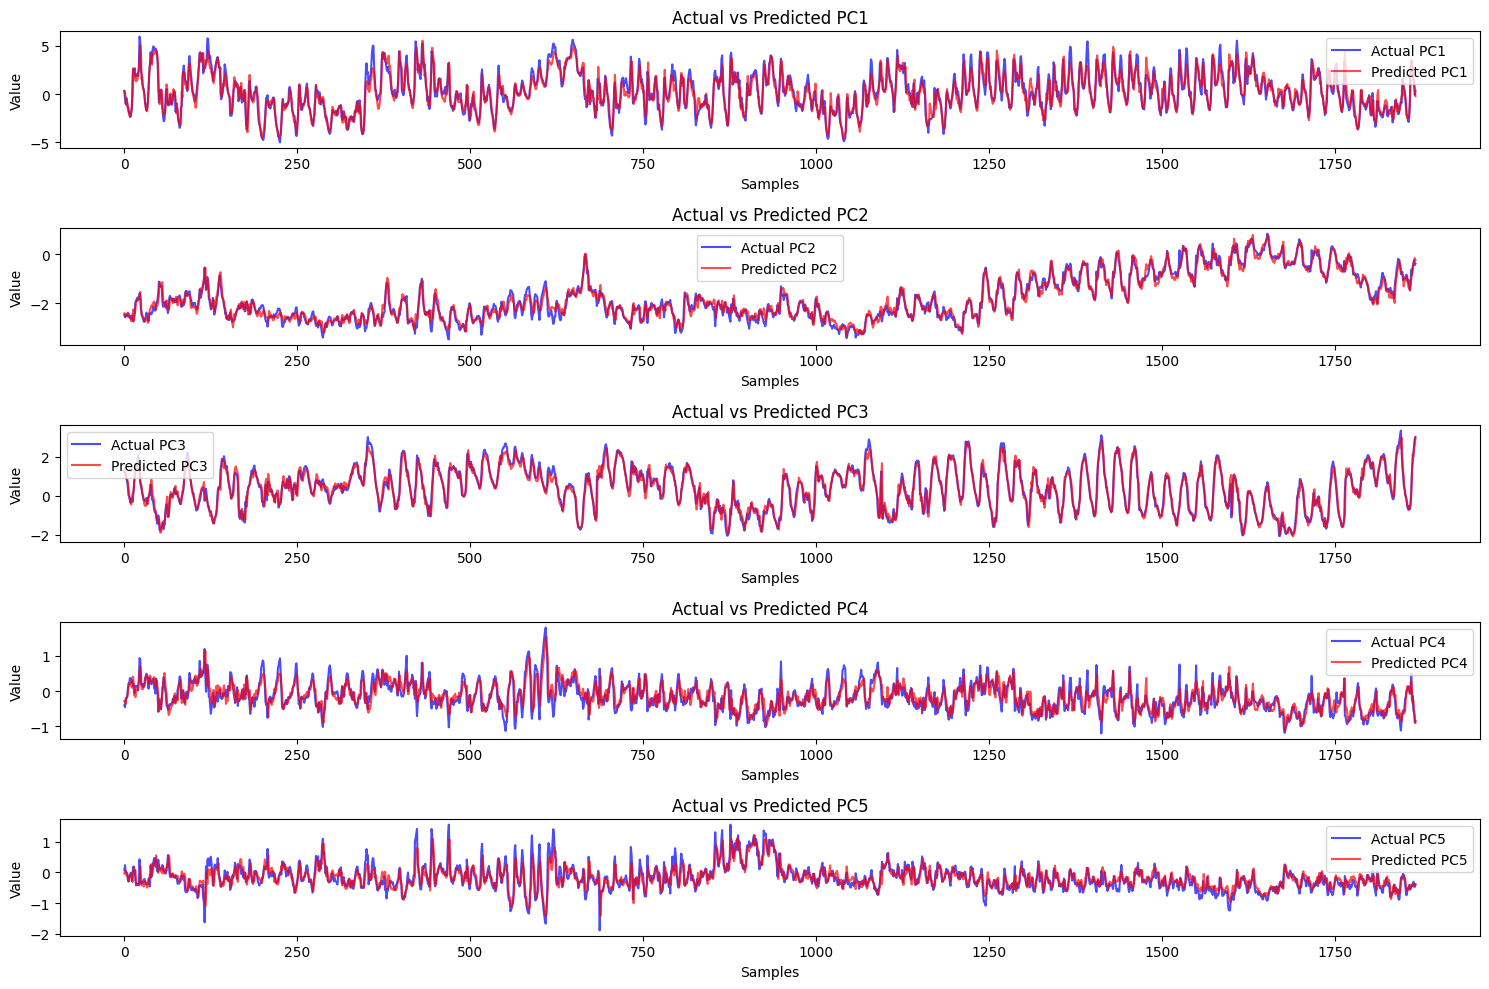

In [54]:
pcs = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
plt.figure(figsize=(15, 10))

for i, pc in enumerate(pcs):
    plt.subplot(len(pcs), 1, i+1)
    plt.plot(y_test[:, i], label=f'Actual {pc}', color='blue', alpha=0.7)
    plt.plot(y_pred[:, i], label=f'Predicted {pc}', color='red', alpha=0.7)
    plt.title(f'Actual vs Predicted {pc}')
    plt.xlabel('Samples')
    plt.ylabel('Value')
    plt.legend()

plt.tight_layout()
plt.show()

#### GRU (RNN) Multivariate

In [ ]:
n_steps = 24
pcs = df_pca.columns.tolist()
df_lags = df_pca.copy()

for col in df_lags.columns:
    for lag in range(1, n_steps+1):
        df_lags[f"{col}_lag{lag}"] = df_lags[col].shift(lag)
df_lags = df_lags.dropna()

X = df_lags.drop(columns=pcs).values.reshape(len(df_lags), n_steps, len(pcs))
y = df_lags[pcs].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = Sequential()
model.add(GRU(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(y_train.shape[1])) 
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
234/234 [==============================] - 4s 9ms/step - loss: 1.0073 - val_loss: 0.9249
Epoch 2/20
234/234 [==============================] - 2s 9ms/step - loss: 0.5570 - val_loss: 0.6736
Epoch 3/20
234/234 [==============================] - 2s 10ms/step - loss: 0.4389 - val_loss: 0.6540
Epoch 4/20
234/234 [==============================] - 3s 11ms/step - loss: 0.3889 - val_loss: 0.5490
Epoch 5/20
234/234 [==============================] - 2s 10ms/step - loss: 0.3521 - val_loss: 0.5019
Epoch 6/20
234/234 [==============================] - 2s 8ms/step - loss: 0.3268 - val_loss: 0.4384
Epoch 7/20
234/234 [==============================] - 2s 9ms/step - loss: 0.2930 - val_loss: 0.4104
Epoch 8/20
234/234 [==============================] - 2s 10ms/step - loss: 0.2783 - val_loss: 0.4326
Epoch 9/20
234/234 [==============================] - 2s 10ms/step - loss: 0.2615 - val_loss: 0.3877
Epoch 10/20
234/234 [==============================] - 2s 9ms/step - loss: 0.2508 - val_loss: 0

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.2872
RMSE: 0.5359
MAE: 0.3912
R²: 0.6124


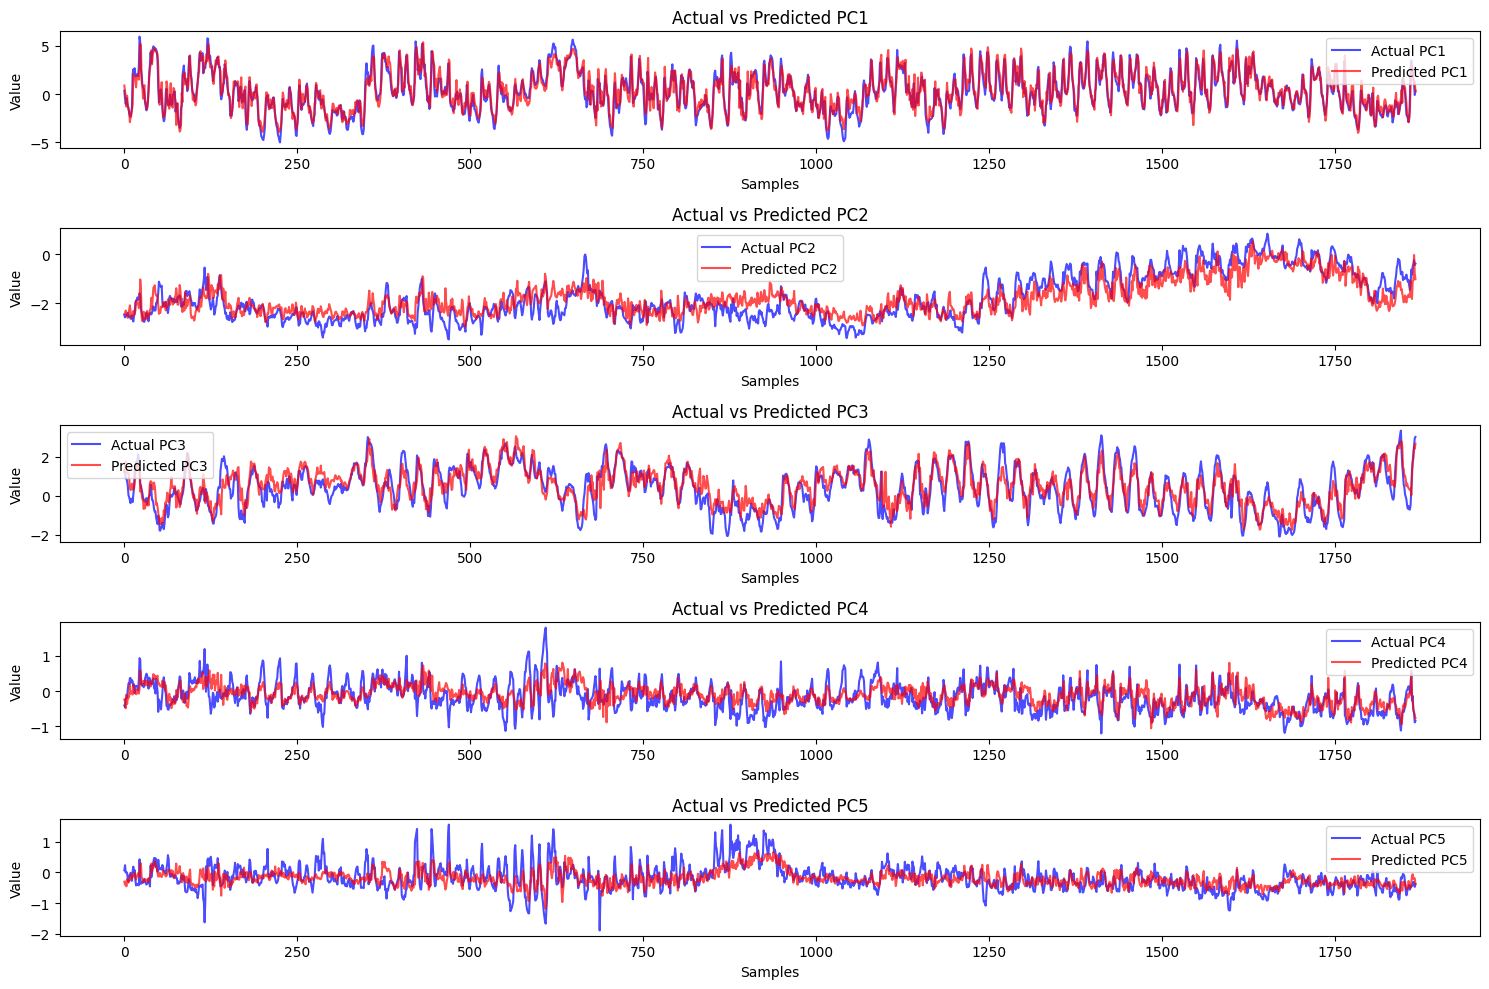

In [64]:
pcs = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
plt.figure(figsize=(15, 10))

for i, pc in enumerate(pcs):
    plt.subplot(len(pcs), 1, i+1)
    plt.plot(y_test[:, i], label=f'Actual {pc}', color='blue', alpha=0.7)
    plt.plot(y_pred[:, i], label=f'Predicted {pc}', color='red', alpha=0.7)
    plt.title(f'Actual vs Predicted {pc}')
    plt.xlabel('Samples')
    plt.ylabel('Value')
    plt.legend()

plt.tight_layout()
plt.show()

##### XGBoost

In [ ]:
n_steps = 24
pcs = df_pca.columns.tolist()

df_lags = df_pca.copy()
for col in df_lags.columns:
    for lag in range(1, n_steps+1):
        df_lags[f"{col}_lag{lag}"] = df_lags[col].shift(lag)

df_lags = df_lags.dropna()

X = df_lags.drop(columns=pcs).values
y = df_lags[pcs].values              

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

multi_xgb = MultiOutputRegressor(xgb_model)
multi_xgb.fit(X_train, y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None, gamma=None,
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
         

In [ ]:
y_pred = multi_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.1512
RMSE: 0.3888
MAE: 0.2472
R²: 0.8307


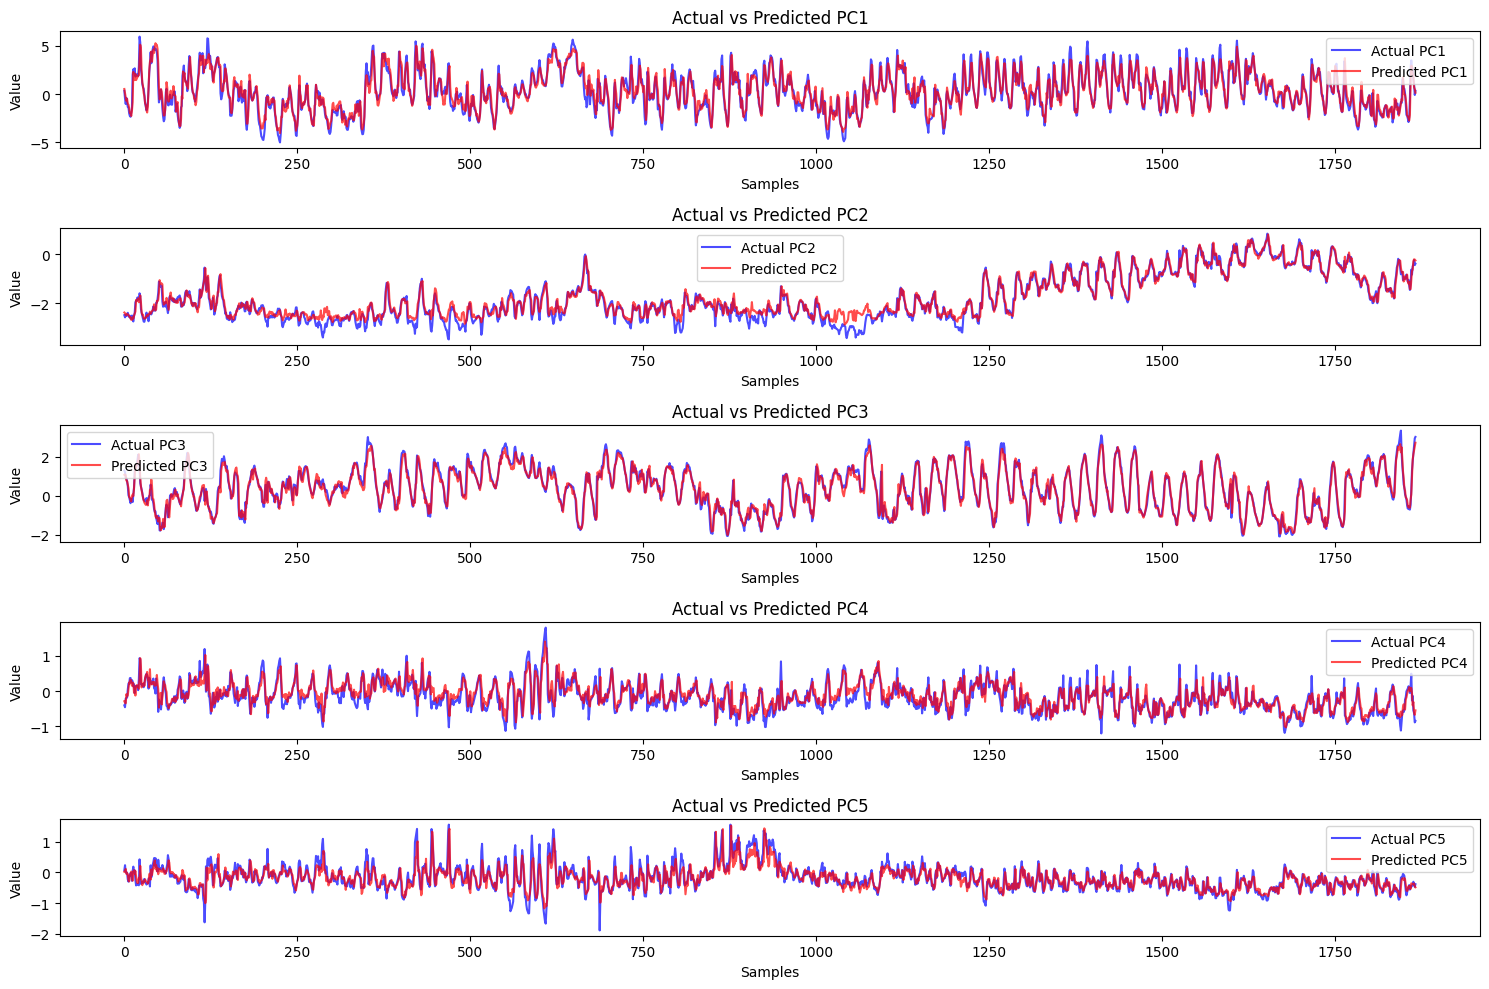

In [67]:
pcs = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
plt.figure(figsize=(15, 10))

for i, pc in enumerate(pcs):
    plt.subplot(len(pcs), 1, i+1)
    plt.plot(y_test[:, i], label=f'Actual {pc}', color='blue', alpha=0.7)
    plt.plot(y_pred[:, i], label=f'Predicted {pc}', color='red', alpha=0.7)
    plt.title(f'Actual vs Predicted {pc}')
    plt.xlabel('Samples')
    plt.ylabel('Value')
    plt.legend()

plt.tight_layout()
plt.show()

#### Time Series Spectral Clustering

In [71]:
X = df_transformed.values.T
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X[:, :, np.newaxis])
X_spectral = np.abs(fft(X_scaled.squeeze(), axis=1))[:, :10]  

sc = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors = min(3, X_spectral.shape[0]-1), random_state=42)
labels = sc.fit_predict(X_spectral)

print("Cluster assignment за секоја серија:")
for i, series_name in enumerate(df_transformed.columns):
    print(f"{series_name} -> Cluster {labels[i]+1}")

Cluster assignment за секоја серија:
NOx(GT) -> Cluster 1
PT08.S3(NOx) -> Cluster 2
NO2(GT) -> Cluster 2
PT08.S4(NO2) -> Cluster 1
PT08.S5(O3) -> Cluster 2
T -> Cluster 1
RH -> Cluster 2
AH -> Cluster 1


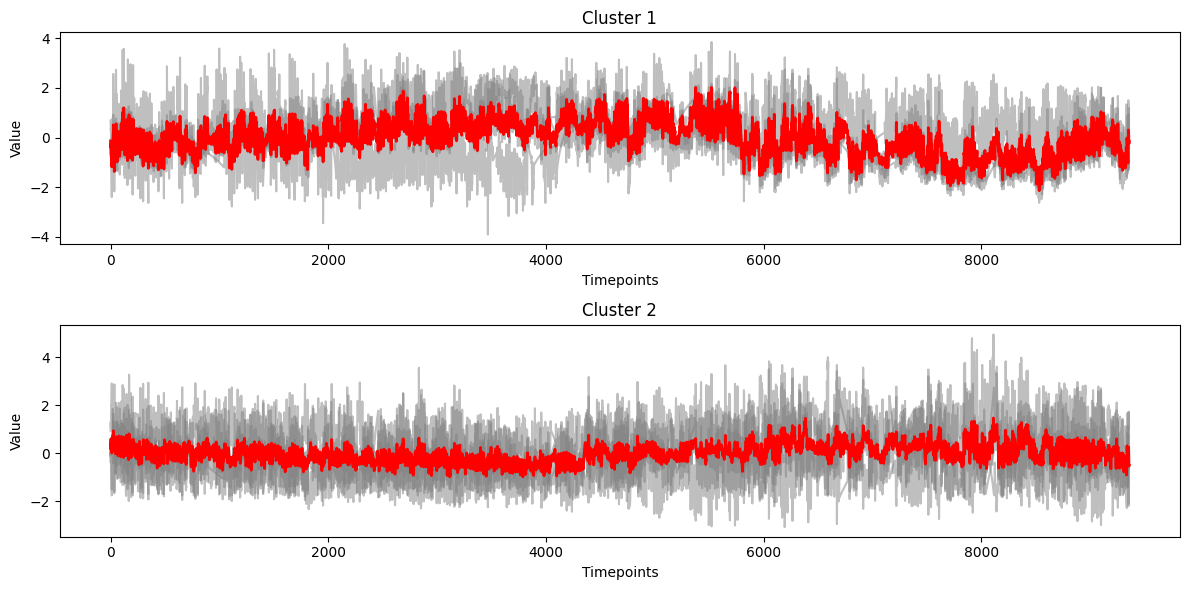

In [73]:
n_clusters = len(np.unique(labels))

plt.figure(figsize=(12, 6))

for cluster in range(n_clusters):
    plt.subplot(n_clusters, 1, cluster+1)
    cluster_series = X_scaled[labels == cluster]
    
    for series in cluster_series:
        plt.plot(series.ravel(), color='gray', alpha=0.5)
    
    centroid = cluster_series.mean(axis=0)
    plt.plot(centroid.ravel(), color='red', linewidth=2)
    
    plt.title(f'Cluster {cluster+1}')
    plt.xlabel('Timepoints')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

#### Hierarchical Clustering

In [75]:
X = df_transformed.values.T  
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X[:, :, np.newaxis])
X_scaled = X_scaled.squeeze()

dist_matrix = cdist_dtw(X_scaled)

linked = linkage(squareform(dist_matrix), method='average')
n_clusters = 2  
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')

print("Cluster assignment за секоја серија:")
for name, label in zip(df_transformed.columns, cluster_labels):
    print(f"{name} -> Cluster {label}")

Cluster assignment за секоја серија:
NOx(GT) -> Cluster 2
PT08.S3(NOx) -> Cluster 2
NO2(GT) -> Cluster 2
PT08.S4(NO2) -> Cluster 1
PT08.S5(O3) -> Cluster 2
T -> Cluster 1
RH -> Cluster 2
AH -> Cluster 1


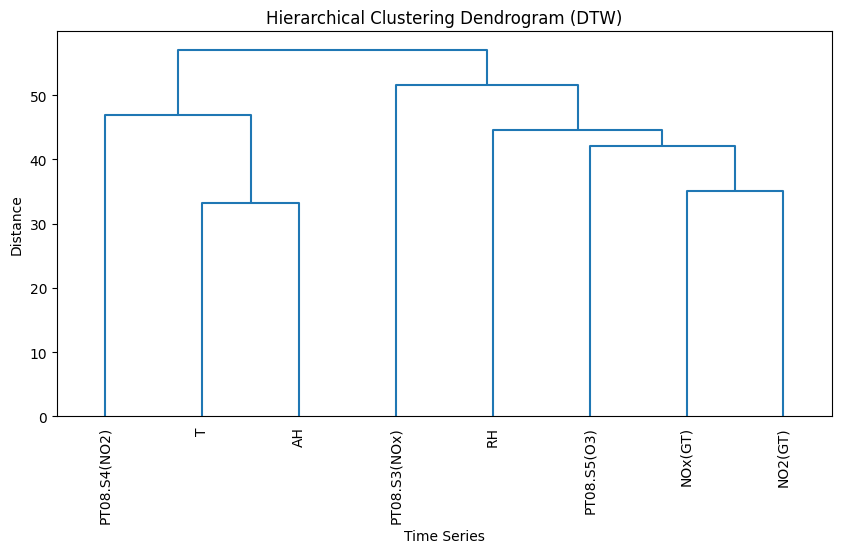

In [ ]:
plt.figure(figsize=(10, 5))
dendrogram(
    linked,
    labels=df_transformed.columns,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0 
)
plt.title("Hierarchical Clustering Dendrogram (DTW)")
plt.ylabel("Distance")
plt.xlabel("Time Series")
plt.show()

### Conclusion

Анализата ја откри динамиката и варијацијата на загадувањето на воздухот, како и 
скриените обрасци во податоците. Резултатите покажуваат дека кластеризацијата и 
анализа на временски серии овозможуваат подобро разбирање и предвидување на 
загадувањето. Загадувањето на воздухот е во голема мера предизвикано од присуството 
на гасовите O3, NOx и NO2, кои директно влијаат на здравјето на луѓето, особено на 
респираторниот систем. Релативната и апсолутната влажност (RH и AH) ја менуваат 
концентрацијата на овие гасови во воздухот, што значи дека условите на воздухот можат 
да го зголемат или намалат ефектот на загадувањето.   
Сето ова помага при креирање на ефективни мерки за заштита на животната средина и 
јавното здравје.

### References

- Vito S. Air Quality [dataset]. 2008. UCI Machine Learning Repository. Available from: https://archive.ics.uci.edu/dataset/360/air+quality
- Paneva, Lina. “Air Quality Time Series Analysis and Forecasting.” Own analysis, 2025.